In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               100000 non-null  object 
 1   sender_account_id            100000 non-null  int64  
 2   receiver_account_id          100000 non-null  int64  
 3   date_id                      100000 non-null  object 
 4   hour                         100000 non-null  int64  
 5   merchant_id                  100000 non-null  int64  
 6   location_id                  100000 non-null  int64  
 7   device_id                    100000 non-null  int64  
 8   amount                       100000 non-null  float64
 9   time_since_last_transaction  100000 non-null  float64
 10  spending_deviation_score     100000 non-null  float64
 11  velocity_score               100000 non-null  float64
 12  geo_anomaly_score            100000 non-null  float64
 13  

,sender_account_id,receiver_account_id,hour,merchant_id,location_id,device_id,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,450639.501090,449874.680840,11.502560,4.500720,4.488180,2.047962e+06,358.562275,-10.303921,-0.005267,10.522840,0.500242
std,259621.496804,259532.878333,6.910357,2.290994,2.284113,1.184771e+06,471.311755,3577.131562,0.996682,5.777573,0.288371
min,4.000000,1.000000,0.000000,1.000000,1.000000,3.000000e+00,0.010000,-8726.752782,-4.630000,1.000000,0.000000
25%,225937.000000,225217.250000,6.000000,2.000000,2.000000,1.027134e+06,26.740000,-2570.163124,-0.670000,6.000000,0.250000
50%,450812.500000,449720.000000,11.000000,4.000000,4.000000,2.039258e+06,137.220000,-2.819035,-0.010000,11.000000,0.500000
75%,677309.000000,674113.750000,18.000000,6.000000,6.000000,3.076357e+06,500.152500,2551.444002,0.670000,16.000000,0.750000
max,899784.000000,899782.000000,23.000000,8.000000,8.000000,4.103429e+06,2954.690000,8706.600354,4.850000,20.000000,1.000000


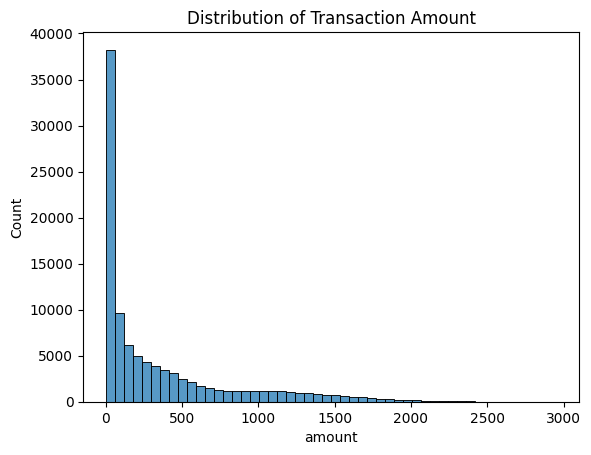

'xem phân bố số tiền giao dịch'

In [ ]:
sns.histplot(df["amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()


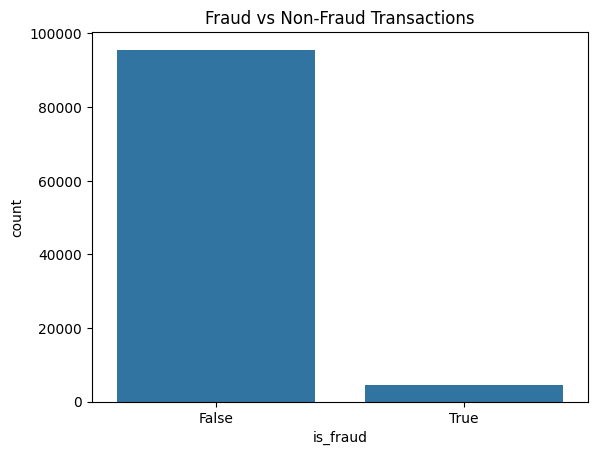

In [ ]:
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()
xem tỷ lệ gian lận.

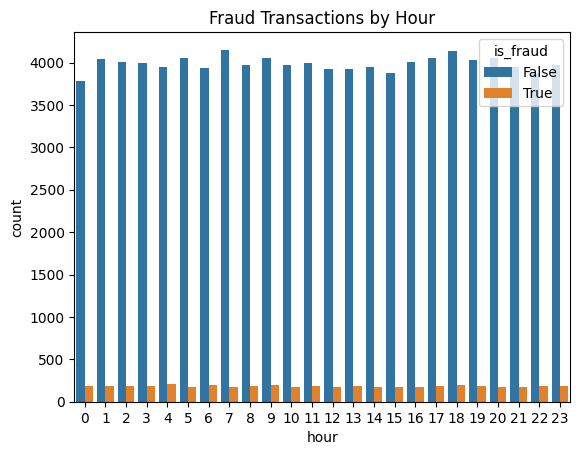

In [ ]:
sns.countplot(x="hour", hue="is_fraud", data=df)
plt.title("Fraud Transactions by Hour")
plt.show()
xem gian lận xảy ra nhiều vào giờ nào

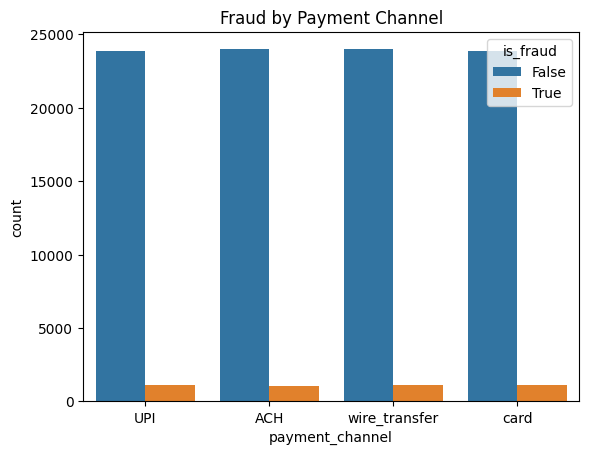

In [ ]:
sns.countplot(x="payment_channel", hue="is_fraud", data=df)
plt.title("Fraud by Payment Channel")
plt.show()
xem kênh thanh toán nào dễ gian lận

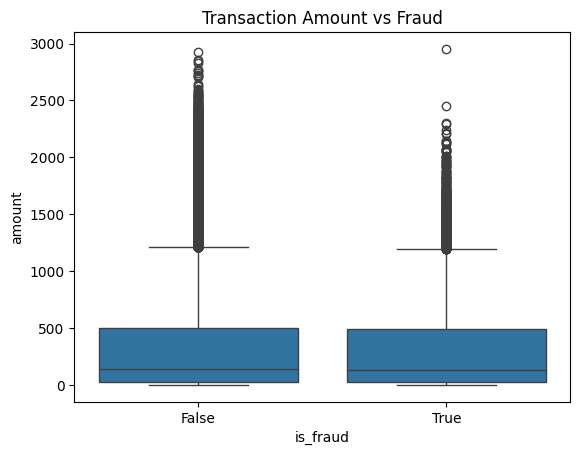

In [ ]:
sns.boxplot(x="is_fraud", y="amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()
so sánh số tiền giao dịch gian lận  vs bình thường

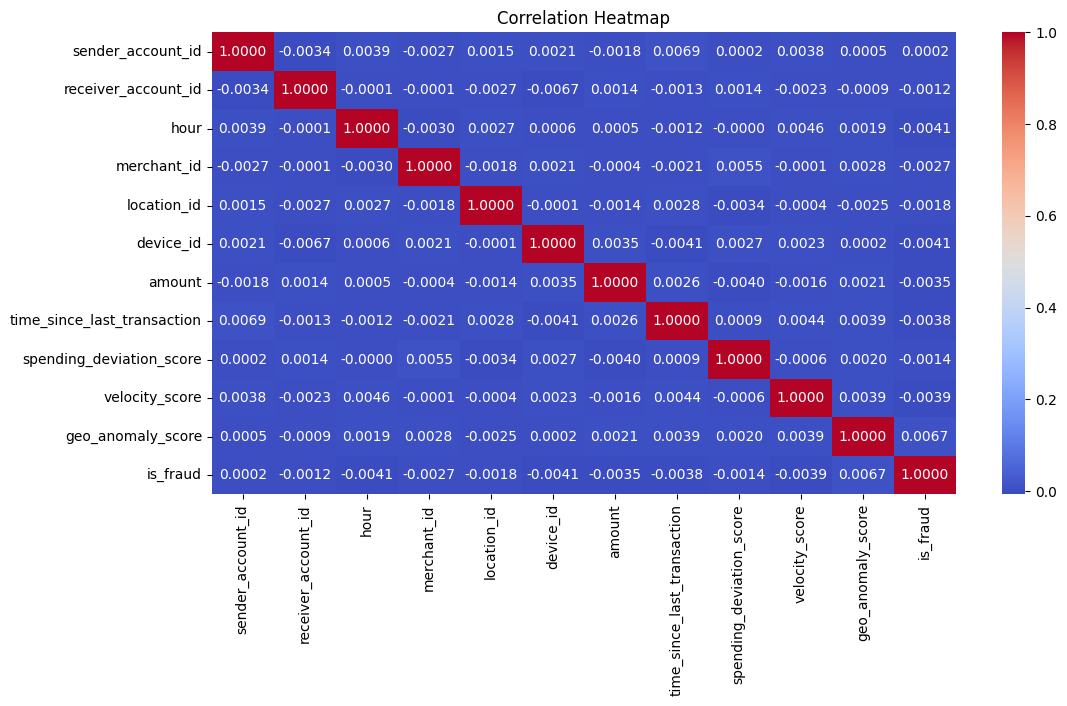

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()
biểu đồ heat map

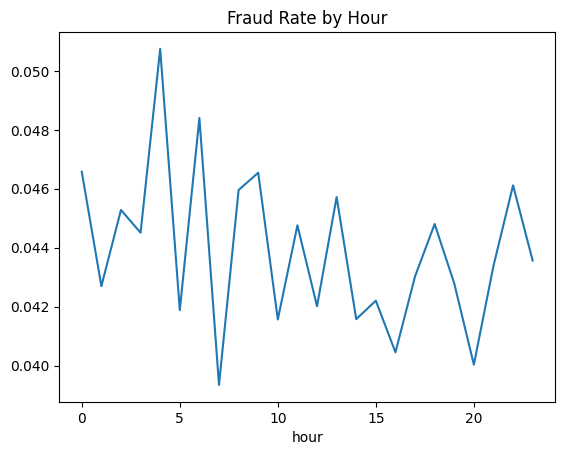

In [ ]:
fraud_rate = df.groupby("hour")["is_fraud"].mean()
fraud_rate.plot()
plt.title("Fraud Rate by Hour")
plt.show()

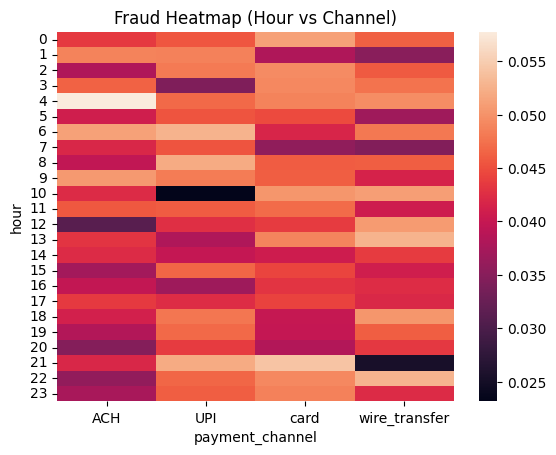

In [ ]:
pivot = df.pivot_table(values="is_fraud",
                       index="hour",
                       columns="payment_channel",
                       aggfunc="mean")

sns.heatmap(pivot)
plt.title("Fraud Heatmap (Hour vs Channel)")
plt.show()

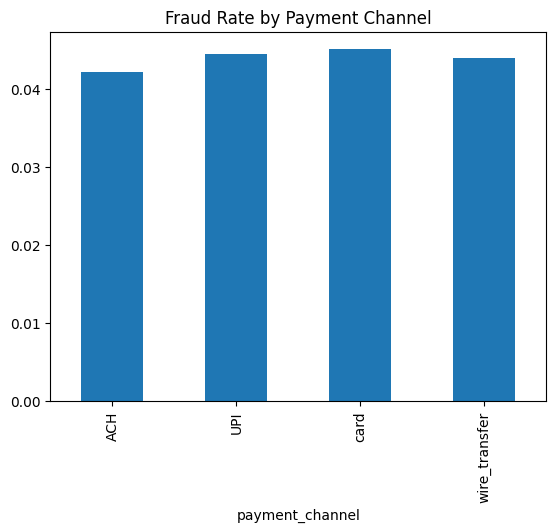

In [ ]:
fraud_channel = df.groupby("payment_channel")["is_fraud"].mean()
fraud_channel.plot(kind="bar")
plt.title("Fraud Rate by Payment Channel")
plt.show()